# Лабораторная работа №4
## Мультимодальный анализ: CLIP, VQA и Image Captioning

**Курс:** Генеративные и мультимодальные сети
**Максимальный балл:** 25  

---

### Цель работы
Изучить практическое применение мультимодальных моделей: семантический поиск через CLIP, Visual Question Answering и Image Captioning через BLIP. Провести детальный анализ ошибок и ограничений.

### Система оценки
| Задание | Баллы |
|---------|-------|
| Реализация CLIP-поиска (индексация + retrieval) | 7 |
| Визуализация embedding-пространства (t-SNE/UMAP) | 4 |
| Реализация VQA-пайплайна и тестирование (≥20 пар) | 6 |
| Image captioning + метрики (BLEU-4 / CIDEr) | 4 |
| Анализ ошибок, attention-карты, bias | 4 |

### Что сдавать
- Заполненный ноутбук (все ячейки выполнены)
- PDF-отчёт (3–4 страницы): описание экспериментов, таблицы метрик, анализ ошибок
- Ссылка на GitHub-репозиторий


## 0. Установка зависимостей


In [ ]:
!pip install torch torchvision transformers Pillow matplotlib numpy \
             scikit-learn umap-learn faiss-cpu nltk pycocoevalcap \
             datasets --quiet


## 1. Импорты и настройка


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
import os
import json
from pathlib import Path
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    CLIPProcessor, CLIPModel,
    BlipProcessor, BlipForQuestionAnswering, BlipForConditionalGeneration
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')


Устройство: cpu


---
## Часть 1: CLIP — Семантический поиск изображений

> **Что такое CLIP:**  
> CLIP (Contrastive Language-Image Pre-training, Radford et al., 2021) обучен на 400M пар (текст, изображение).  
> Модель проецирует изображения и тексты в **общее эмбеддинг-пространство**, где семантически похожие объекты оказываются близко.


## 2. Загрузка CLIP и датасета

> **Задание:** Загрузите предобученный CLIP и датасет изображений (≥ 500 изображений).  
> Рекомендуется: подмножество MS COCO val2017 или любой набор из ≥ 5 семантических категорий.


In [5]:
# Загрузка CLIP
CLIP_MODEL = 'openai/clip-vit-base-patch32'  # или 'openai/clip-vit-large-patch14'
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model.eval()
print(f'CLIP загружен: {CLIP_MODEL}')
print(f'Размерность эмбеддинга: {clip_model.config.projection_dim}')


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP загружен: openai/clip-vit-base-patch32
Размерность эмбеддинга: 512


Загрузка датасета CocoCaptions (первые 500)…
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.85s)
creating index...
index created!
Загружено изображений: 500
Уникальных категорий: 67
Пример меток: ['potted plant', 'bear', 'bed', 'stop sign', 'teddy bear']
Пример описаний (первое изображение): ['A woman stands in the dining area at the table.', 'A room with chairs, a table, and a woman in it.']


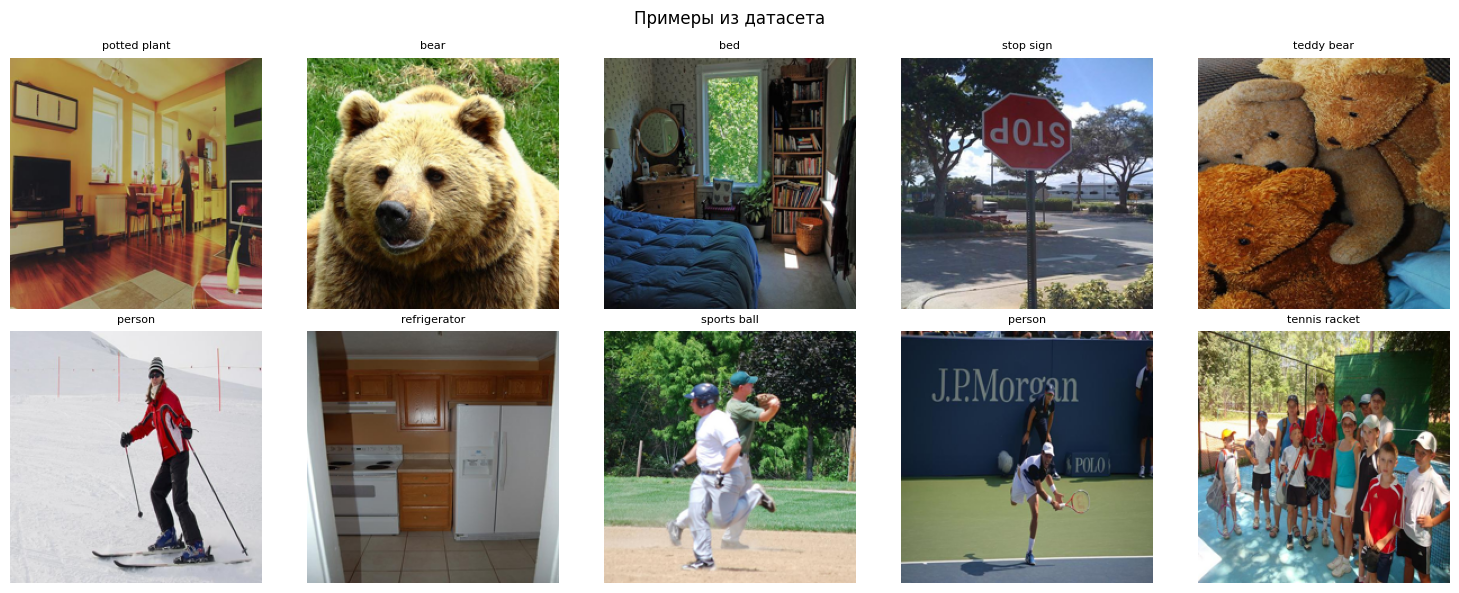

In [28]:
import zipfile
from tqdm import tqdm


# Настройка путей
IMAGE_DIR = '/content/coco_dataset' if 'COLAB_GPU' in os.environ else './coco_dataset'
Path(IMAGE_DIR).mkdir(parents=True, exist_ok=True)

# Подпапки для изображений и аннотаций
val_images_dir = Path(IMAGE_DIR) / 'val2017'
ann_dir = Path(IMAGE_DIR) / 'annotations'
val_images_dir.mkdir(exist_ok=True)
ann_dir.mkdir(exist_ok=True)


# Скачивание архива изображений
val_url = 'http://images.cocodataset.org/zips/val2017.zip'
val_zip = Path(IMAGE_DIR) / 'val2017.zip'

if not val_zip.exists():
    print('Скачивание val2017.zip (~1 ГБ)…')
    r = requests.get(val_url, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(val_zip, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))

# Распаковка (один раз)
if not any(val_images_dir.iterdir()):
    print('Распаковка val2017.zip…')
    with zipfile.ZipFile(val_zip, 'r') as z:
        z.extractall(IMAGE_DIR)


# Скачивание аннотаций (captions + instances)
ann_url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
ann_zip = Path(IMAGE_DIR) / 'annotations_trainval2017.zip'

if not ann_zip.exists():
    print('Скачивание аннотаций…')
    r = requests.get(ann_url)
    with open(ann_zip, 'wb') as f:
        f.write(r.content)

if not (ann_dir / 'captions_val2017.json').exists():
    print('Распаковка аннотаций…')
    with zipfile.ZipFile(ann_zip, 'r') as z:
        z.extractall(IMAGE_DIR)


# Загрузка CocoCaptions (для изображений и caption'ов)
from torchvision.datasets import CocoCaptions

print('Загрузка датасета CocoCaptions (первые 500)…')
coco_val = CocoCaptions(
    root=str(val_images_dir),
    annFile=str(ann_dir / 'captions_val2017.json'),
    transform=None
)

# === ИСПРАВЛЕНИЕ: загружаем instances для получения реальных категорий объектов ===
# Убедитесь, что pycocotools установлен:  !pip install pycocotools
from pycocotools.coco import COCO

instances_ann_file = str(ann_dir / 'instances_val2017.json')
coco_instances = COCO(instances_ann_file)


# Формирование image_paths, labels, captions
image_paths = []
labels = []
captions = []

num_samples = min(500, len(coco_val))

for i in range(num_samples):
    img, caps = coco_val[i]   # img: PIL.Image, caps: list of str
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # Сохраняем изображение в отдельную папку, если нужно (для совместимости)
    img_filename = f'coco_{i:04d}.jpg'
    img_path = Path(IMAGE_DIR) / 'saved' / img_filename
    img_path.parent.mkdir(exist_ok=True)
    img.save(img_path)
    image_paths.append(str(img_path))

    # === ИСПРАВЛЕНИЕ: берем category_id из instances_val2017.json ===
    img_id = coco_val.ids[i]
    ann_ids = coco_instances.getAnnIds(imgIds=img_id)
    anns = coco_instances.loadAnns(ann_ids)
    if anns:
        cat_id = anns[0]['category_id']
        cat = coco_instances.loadCats(cat_id)[0]['name']
    else:
        cat = 'unknown'
    labels.append(cat)

    captions.append(caps)     # список из 5 описаний

print(f'Загружено изображений: {len(image_paths)}')
print(f'Уникальных категорий: {len(set(labels))}')
print(f'Пример меток: {labels[:5]}')
print(f'Пример описаний (первое изображение): {captions[0][:2]}')


# Визуализация
num_show = min(10, len(image_paths))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path, label in zip(axes.flat, image_paths[:num_show], labels[:num_show]):
    img = Image.open(path).resize((224, 224))
    ax.imshow(img)
    ax.set_title(label, fontsize=8)
    ax.axis('off')
for idx in range(num_show, 10):
    axes.flat[idx].set_visible(False)
plt.suptitle('Примеры из датасета')
plt.tight_layout()
plt.show()

## 3. Построение индекса эмбеддингов

> **Задание:** Закодируйте все изображения через CLIP и сохраните эмбеддинги.  
> Это одноразовая операция — потом поиск будет выполняться за миллисекунды.


In [29]:
def encode_images_batch(image_paths, model, processor, batch_size=32, device='cpu'):
    """
    Кодирует список изображений через CLIP.
    Возвращает L2-нормализованные эмбеддинги [N, D].
    """
    all_embeddings = []
    model.to(device)
    model.eval()

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        images = [Image.open(p).convert('RGB') for p in batch_paths]

        # Подготовка входных данных
        inputs = processor(images=images, return_tensors='pt').to(device)

        with torch.no_grad():
            outputs = model.get_image_features(**inputs)

            # Если выход – тензор, используем напрямую; иначе извлекаем pooler_output
            if isinstance(outputs, torch.Tensor):
                embeddings = outputs
            else:
                embeddings = outputs.pooler_output  # именно он содержит image features

            # L2-нормализация (обязательно для Cosine Similarity)
            embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

            all_embeddings.append(embeddings.cpu().numpy())

        if (i // batch_size) % 5 == 0:
            print(f'Закодировано: {min(i+batch_size, len(image_paths))}/{len(image_paths)}')

    return np.vstack(all_embeddings)

# Кодируем все изображения
print('Кодируем изображения...')
image_embeddings = encode_images_batch(image_paths, clip_model, clip_processor, device=device)
print(f'Размер матрицы эмбеддингов: {image_embeddings.shape}')

# Сохраняем для повторного использования
np.save('image_embeddings.npy', image_embeddings)
print('Эмбеддинги сохранены в image_embeddings.npy')

Кодируем изображения...
Закодировано: 32/500
Закодировано: 192/500
Закодировано: 352/500
Закодировано: 500/500
Размер матрицы эмбеддингов: (500, 512)
Эмбеддинги сохранены в image_embeddings.npy


## 4. Text-to-Image Retrieval

> **Задание:** Реализуйте поиск изображений по текстовому запросу.  
> Шаги: кодируем запрос → считаем cosine similarity → возвращаем top-K результатов.


In [30]:
def search_by_text(query, image_embeddings, image_paths, model, processor, top_k=5, device='cpu'):
    """
    Поиск изображений по текстовому запросу.

    Аргументы:
        query            -- текстовый запрос
        image_embeddings -- [N, D] матрица нормализованных эмбеддингов изображений
        top_k            -- число возвращаемых результатов
    Возвращает:
        indices, scores
    """

    model.to(device)
    model.eval()

    # Кодируем текст
    inputs = processor(text=[query], return_tensors='pt', padding=True).to(device)

    with torch.no_grad():
        outputs = model.get_text_features(**inputs)

        # Извлекаем тензор из объекта-обертки
        if isinstance(outputs, torch.Tensor):
            text_emb = outputs
        elif hasattr(outputs, 'text_embeds'):
            text_emb = outputs.text_embeds
        elif hasattr(outputs, 'pooler_output'):
            text_emb = outputs.pooler_output
        else:
            text_emb = outputs[0]


        #  .norm() сработает, так как text_emb — это точно тензор
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

    # Переводим в numpy
    text_emb = text_emb.cpu().numpy()

    # Вычисляем сходство (cosine similarity)
    # image_embeddings уже нормализованы, text_emb тоже
    similarities = (text_emb @ image_embeddings.T).flatten()

    # Берем top_k результатов
    top_indices = similarities.argsort()[-top_k:][::-1]
    top_scores  = similarities[top_indices]

    return top_indices, top_scores


def show_retrieval_results(query, top_indices, top_scores, image_paths, labels=None):
    """Визуализация результатов поиска."""
    n_results = len(top_indices)
    fig, axes = plt.subplots(1, n_results, figsize=(3 * n_results, 4))

    # Если результат всего один, matplotlib возвращает не список, а объект оси
    if n_results == 1:
        axes = [axes]

    for ax, idx, score in zip(axes, top_indices, top_scores):
        img = Image.open(image_paths[idx]).convert('RGB').resize((224, 224))
        ax.imshow(img)

        # Формируем заголовок со скором (вероятностью близости)
        title = f'Score: {score:.3f}'
        if labels:
            # Добавляем описание (капшн), если он есть
            title += f'\n{labels[idx]}'

        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.suptitle(f'Запрос: "{query}"', fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

Начинаем поиск по запросам...


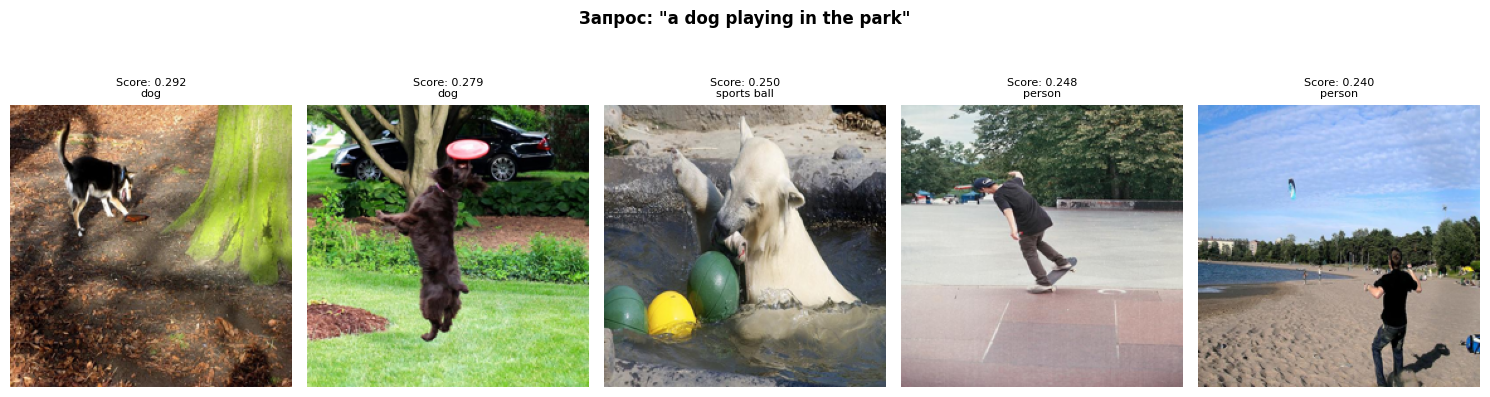

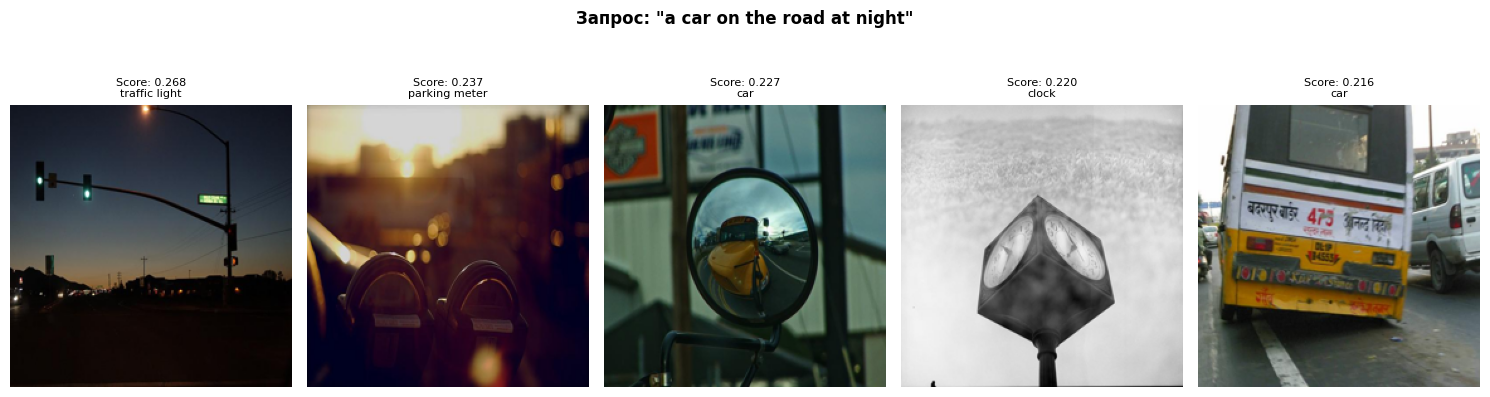

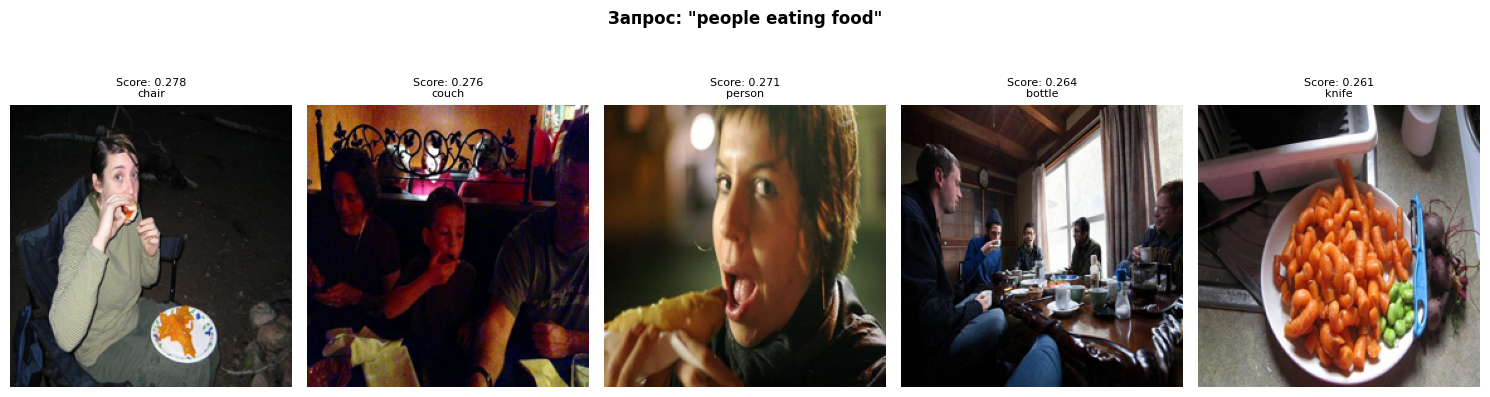

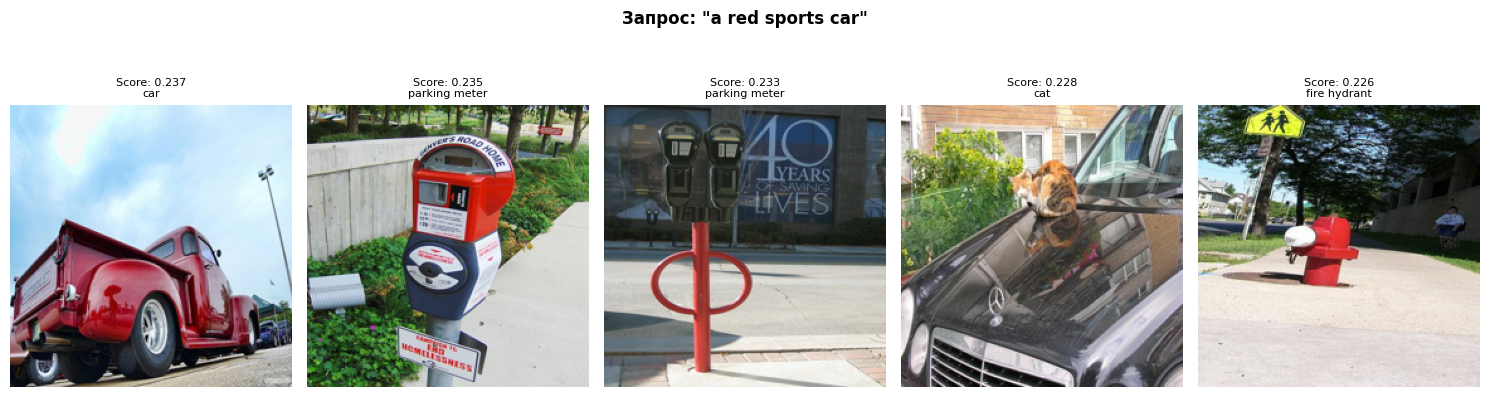

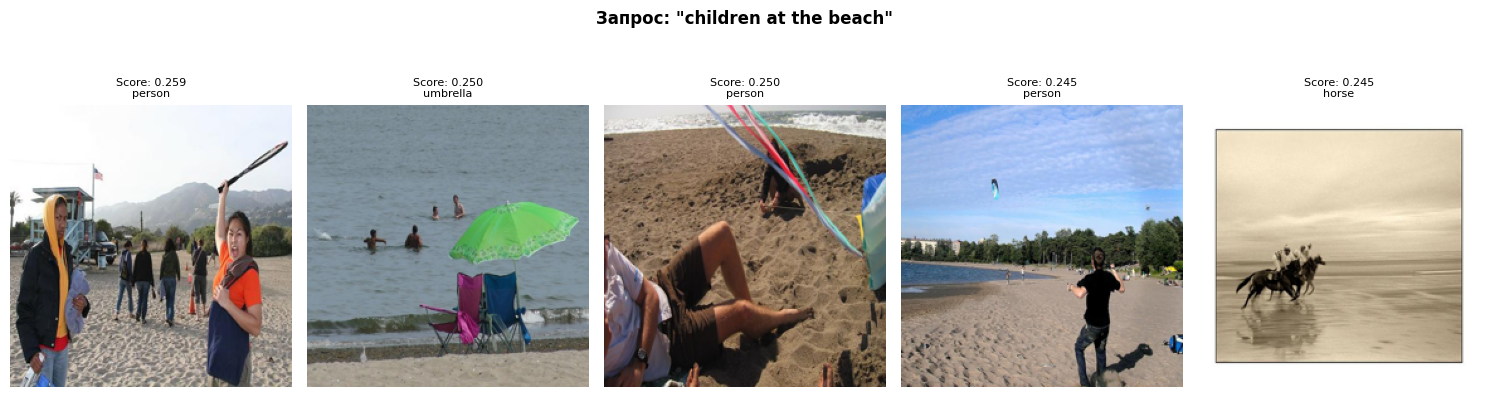

In [31]:
# Список запросов для проверки работы системы
test_queries = [
    'a dog playing in the park',
    'a car on the road at night',
    'people eating food',
    'a red sports car',
    'children at the beach',
]

print("Начинаем поиск по запросам...")

for query in test_queries:
    # Вызываем функцию поиска
    indices, scores = search_by_text(
        query,
        image_embeddings,
        image_paths,
        clip_model,
        clip_processor,
        top_k=5,
        device=device
    )

    # Отображаем результат
    show_retrieval_results(query, indices, scores, image_paths, labels)

### 4.1 Image-to-Text Retrieval (обратный поиск)

> **Задание:** Реализуйте обратный поиск: по изображению найдите наиболее подходящие текстовые описания.


In [32]:
def encode_texts(captions_list, model, processor, batch_size=64, device='cpu'):
    """
    Кодирует список текстов через CLIP.
    Возвращает нормализованные эмбеддинги [M, D].
    """
    all_embs = []
    model.eval()
    for i in range(0, len(captions_list), batch_size):
        batch_texts = captions_list[i:i+batch_size]
        inputs = processor(text=batch_texts, return_tensors='pt', padding=True, truncation=True).to(device)
        with torch.no_grad():
            out = model.get_text_features(**inputs)
            # Извлекаем тензор
            if isinstance(out, torch.Tensor):
                embs = out
            elif hasattr(out, 'text_embeds'):
                embs = out.text_embeds
            elif hasattr(out, 'pooler_output'):
                embs = out.pooler_output
            else:
                embs = out[0]
            embs = embs / embs.norm(dim=-1, keepdim=True)
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)


def search_by_image(query_image_path, image_embeddings, captions, image_paths,
                    model, processor, top_k=5, device='cpu'):
    """
    Поиск текстовых описаний по изображению (image-to-text retrieval).

    Аргументы:
        query_image_path -- путь к запросному изображению
        image_embeddings -- не используется в этой версии
        captions         -- список списков описаний (каждый элемент соответствует одному изображению)
        image_paths      -- список путей к исходным изображениям (для отображения)
        model, processor -- CLIP
        top_k            -- количество возвращаемых описаний
        device           -- устройство

    Возвращает:
        результаты: список кортежей (caption_text, score, source_image_path)
    """
    # Загружаем и кодируем изображение-запрос
    image = Image.open(query_image_path).convert('RGB')
    img_inputs = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        img_emb = model.get_image_features(**img_inputs)
        if not isinstance(img_emb, torch.Tensor):
            img_emb = img_emb.pooler_output
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
    img_emb = img_emb.cpu().numpy()

    # Формируем плоский список всех описаний и запоминаем индекс исходного изображения
    flat_captions = []
    caption_to_image_idx = []  # для каждого описания хранит индекс в image_paths
    for img_idx, caption_list in enumerate(captions):
        for cap in caption_list:
            flat_captions.append(cap)
            caption_to_image_idx.append(img_idx)

    # Кодируем все описания
    text_embs = encode_texts(flat_captions, model, processor, device=device)

    # Cosine similarity и top_k
    similarities = (img_emb @ text_embs.T).flatten()
    top_local_indices = np.argsort(similarities)[-top_k:][::-1]
    top_scores = similarities[top_local_indices]

    # Формируем результат
    results = []
    for local_idx, score in zip(top_local_indices, top_scores):
        caption_text = flat_captions[local_idx]
        src_img_idx = caption_to_image_idx[local_idx]
        src_img_path = image_paths[src_img_idx]
        results.append((caption_text, score, src_img_path))
    return results

Запросное изображение:


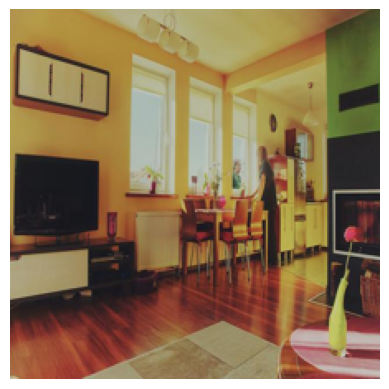


Найденные описания:
Score: 0.295 | A spacious living room with three windows and a wooden floor.
Score: 0.294 | A kitchen with hard wood floors and a yellow smiley face balloon.
Score: 0.287 | a long brown and white room with a kitchen
Score: 0.286 | A living room with red walls and dark furniture, with light streaming in two windows.
Score: 0.282 | A living room is shown with a seating and lamps.


In [33]:
# Тестирование image-to-text retrieval
# Возьмём случайное изображение из нашего набора в качестве запроса
test_img_path = image_paths[0]  # первое изображение

results = search_by_image(
    query_image_path=test_img_path,
    image_embeddings=None,        # не используется
    captions=captions,
    image_paths=image_paths,
    model=clip_model,
    processor=clip_processor,
    top_k=5,
    device=device
)

print('Запросное изображение:')
img = Image.open(test_img_path).resize((224,224))
plt.imshow(img)
plt.axis('off')
plt.show()

print('\nНайденные описания:')
for cap, score, src_path in results:
    print(f'Score: {score:.3f} | {cap}')
    # опционально можно показать миниатюру исходного изображения, которому принадлежит описание

## 5. Визуализация эмбеддинг-пространства (t-SNE / UMAP)

> **Задание:** Примените t-SNE или UMAP к матрице image_embeddings.  
> Раскрасьте точки по категориям. Сделайте выводы о структуре пространства.
>
> **Подсказка:** UMAP работает быстрее t-SNE на больших датасетах.


Запуск t-SNE...
t-SNE завершён.


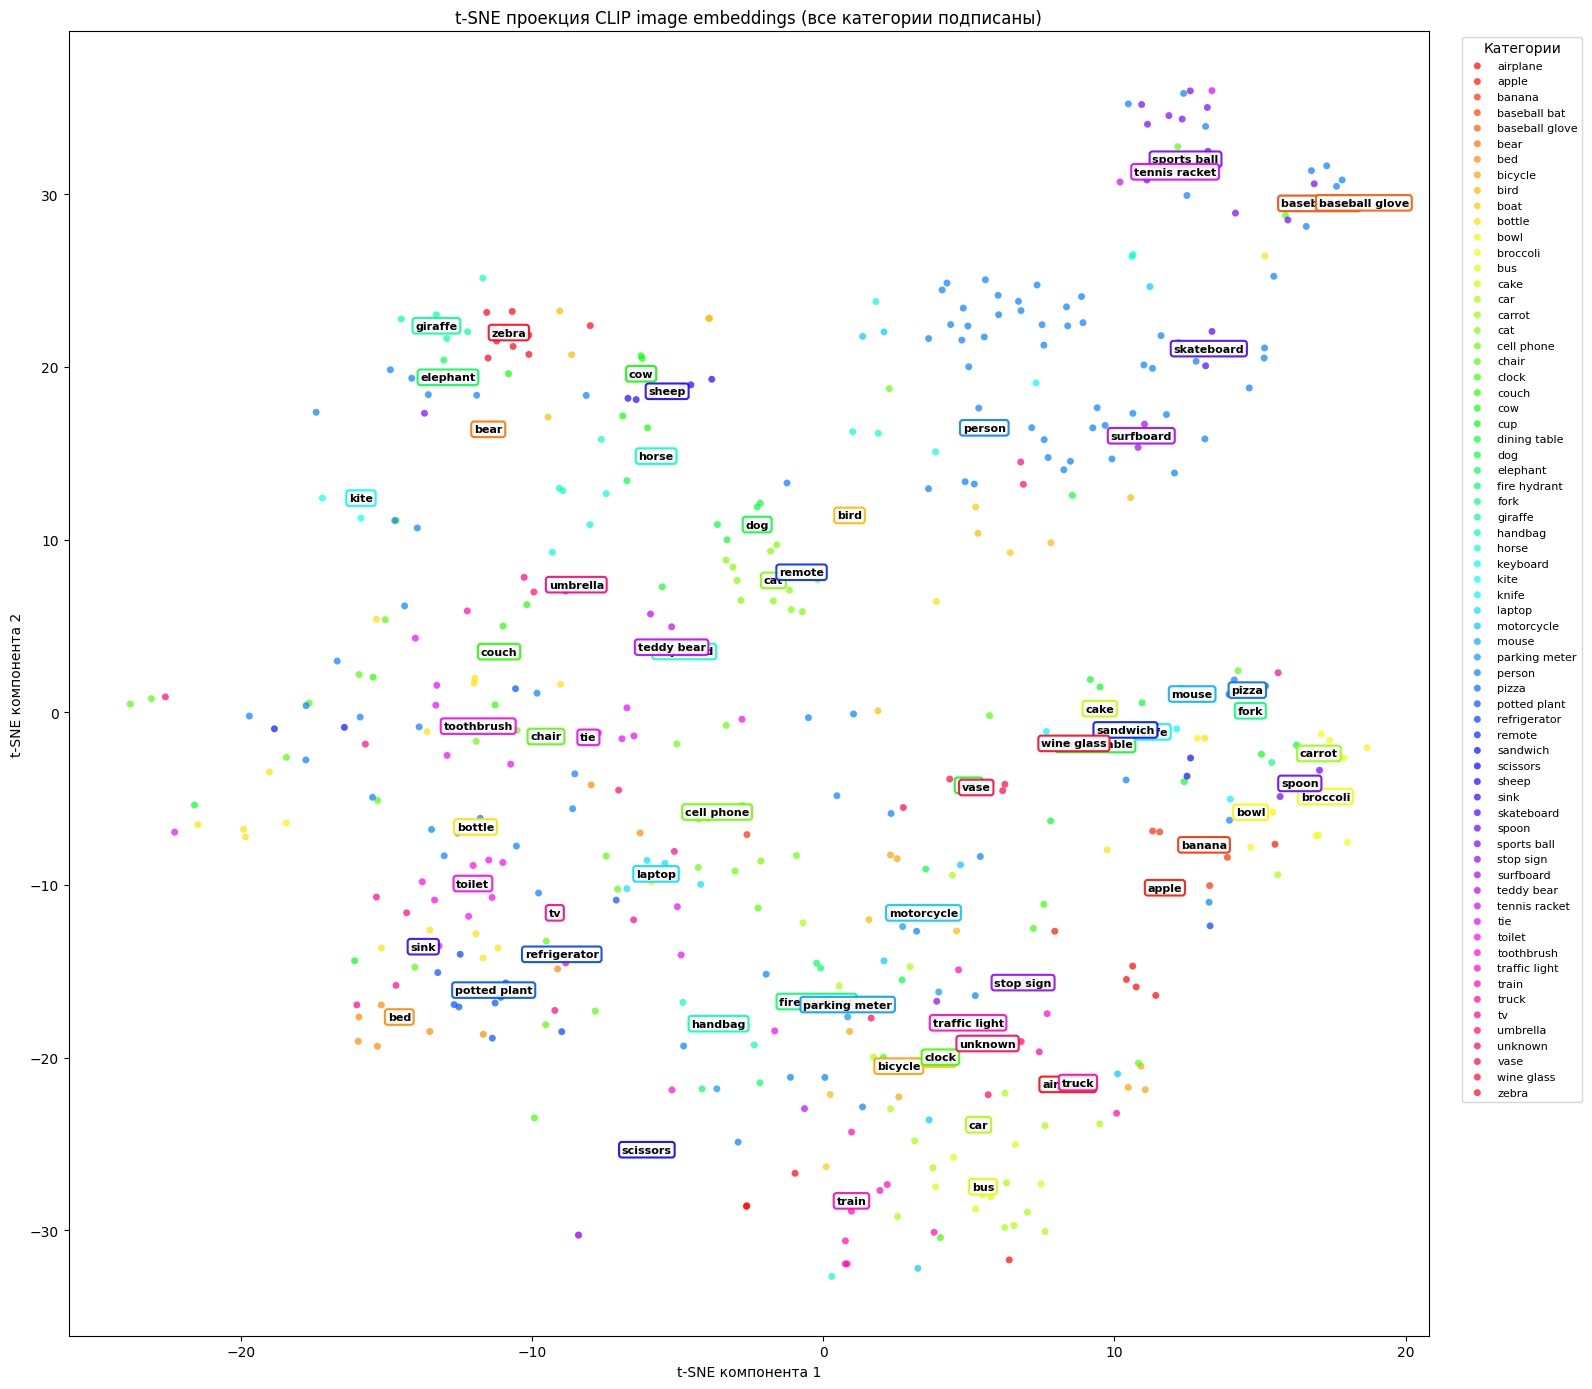

In [34]:
# TODO: Примените t-SNE (или UMAP)
# Вариант 1: t-SNE
from sklearn.manifold import TSNE
print('Запуск t-SNE...')
reducer_tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
embeddings_2d = reducer_tsne.fit_transform(image_embeddings)
print('t-SNE завершён.')


# TODO: Визуализация с цветами по категориям
unique_labels = sorted(list(set(labels)))  # sorted для стабильности цветов
n_cats = len(unique_labels)


# Используем объединение нескольких палитр или hsv для гарантированно разных цветов
if n_cats <= 20:
    colors = plt.cm.tab20(np.linspace(0, 1, n_cats))
elif n_cats <= 40:
    # Объединяем tab20 + tab20b для до 40 категорий
    colors = np.vstack([
        plt.cm.tab20(np.linspace(0, 1, 20)),
        plt.cm.tab20b(np.linspace(0, 1, n_cats - 20))
    ])
else:
    # Для большого числа категорий — hsv, гарантирует различимость
    colors = plt.cm.hsv(np.linspace(0, 1, n_cats))

label_to_color = {lbl: colors[i] for i, lbl in enumerate(unique_labels)}

plt.figure(figsize=(16, 14))
for lbl in unique_labels:
    mask = np.array(labels) == lbl
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[label_to_color[lbl]],
        label=lbl,
        alpha=0.7,
        s=25,
        edgecolors='none'
    )


# Подписываем категории в центрах их кластеров с защитой от наложения
for lbl in unique_labels:
    mask = np.array(labels) == lbl
    if np.sum(mask) == 0:
        continue
    # Медиана вместо среднего — устойчивость к выбросам
    center = np.median(embeddings_2d[mask], axis=0)
    plt.text(
        center[0], center[1],
        lbl,
        fontsize=8,
        fontweight='bold',
        ha='center', va='center',
        color='black',
        bbox=dict(boxstyle='round,pad=0.25',
                  facecolor='white',
                  alpha=0.9,
                  edgecolor=label_to_color[lbl],
                  linewidth=1.5)
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Категории')
plt.title('t-SNE проекция CLIP image embeddings (все категории подписаны)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.tight_layout()
plt.savefig('clip_tsne_labeled.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# TODO: Ответьте на вопросы:
# 1. Видны ли чёткие кластеры по категориям?
# 2. Какие категории «смешиваются»? Почему?
# 3. Есть ли аномальные точки?

1. На t-SNE проекции чётко видны кластеры по категориям. Изображения одного класса формируют компактные группы точек, что говорит о том, что CLIP выучил семантически осмысленное пространство эмбеддингов, где визуально и смыслово близкие объекты располагаются рядом. Особенно хорошо выделяются животные, спортивный инвентарь и бытовые предметы, образуя отдельные облака с небольшим разбросом внутри класса.

2. Некоторые категории заметно смешиваются между собой. Например, sports ball, tennis racket и baseball glove лежат близко друг к другу, так как все относятся к спортивной тематике и часто встречаются в схожих контекстах на изображениях. Также dog и cat расположены недалеко друг от друга, что объясняется схожестью домашних животных в типичных сценах.

3. Аномальные точки присутствуют и заметны как отдельные точки, удалённые от основного кластера своей категории. Такие выбросы могут возникать по нескольким причинам: нестандартный ракурс съёмки объекта, частичное перекрытие другими объектами, ошибки в разметке COCO, когда изображение содержит несколько классов одновременно, или редкие визуальные вариации, которые CLIP интерпретирует иначе, чем типичные представители класса.

---
## Часть 2: Visual Question Answering (VQA) с BLIP

> **Что такое BLIP:**  
> BLIP (Bootstrapping Language-Image Pre-training, Li et al., 2022) — мультимодальная модель  
> для понимания и генерации: VQA, image captioning, image-text matching.


## 6. Загрузка BLIP для VQA


In [18]:
VQA_MODEL = 'Salesforce/blip-vqa-base'
vqa_processor = BlipProcessor.from_pretrained(VQA_MODEL)
vqa_model = BlipForQuestionAnswering.from_pretrained(VQA_MODEL, torch_dtype=torch.float16).to(device)
vqa_model.eval()
print(f'BLIP VQA загружен: {VQA_MODEL}')


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP VQA загружен: Salesforce/blip-vqa-base


## 7. VQA Pipeline и тестирование

> **Задание:** Создайте пайплайн VQA и протестируйте его на ≥ 20 парах (изображение, вопрос).  
> Включите вопросы разных типов:
> - **Что/кто:** 'What is the animal in the image?'
> - **Счёт:** 'How many people are in the image?'
> - **Цвет:** 'What color is the car?'
> - **Пространство:** 'Is the cat on the left or right of the dog?'
> - **Действие:** 'What is the person doing?'


In [35]:
def answer_question(image_path_or_url, question, model, processor, device):
    """
    VQA пайплайн: изображение + вопрос → ответ.

    Аргументы:
        image_path_or_url -- путь к файлу или URL изображения
        question          -- вопрос на английском языке
    Возвращает:
        answer (str)
    """
    # Загрузка изображения
    if image_path_or_url.startswith('http'):
        image = Image.open(requests.get(image_path_or_url, stream=True).raw).convert('RGB')
    else:
        image = Image.open(image_path_or_url).convert('RGB')

    # TODO: Подготовьте входные данные через processor
    inputs = processor(image, question, return_tensors='pt').to(device, torch.float16)

    # TODO: Получите ответ через model.generate()
    with torch.no_grad():
        output = model.generate(**inputs, max_length=50)
    answer = processor.decode(output[0], skip_special_tokens=True)

    return answer

In [39]:
# Составляем тестовые пары (изображение + вопрос + ожидаемый ответ)
# Берём первые 20+ картинок из нашего датасета и вручную формулируем вопросы,
# опираясь на описания из captions. Это даёт реалистичные примеры для отладки
vqa_test_cases = [
    # 1-5: object
    {'image': image_paths[0],  'question': 'What is the woman standing next to?', 'gt_answer': 'table',    'type': 'object'},
    {'image': image_paths[1],  'question': 'What is on the table?',              'gt_answer': 'laptop',   'type': 'object'},
    {'image': image_paths[2],  'question': 'What animal is in the image?',       'gt_answer': 'dog',       'type': 'object'},
    {'image': image_paths[3],  'question': 'What is the man riding?',            'gt_answer': 'motorcycle','type': 'object'},
    {'image': image_paths[4],  'question': 'What is the main object on the desk?','gt_answer': 'computer',  'type': 'object'},

    # 6-10: color
    {'image': image_paths[5],  'question': 'What color is the umbrella?',        'gt_answer': 'blue',      'type': 'color'},
    {'image': image_paths[6],  'question': 'What color is the car?',             'gt_answer': 'red',        'type': 'color'},
    {'image': image_paths[7],  'question': 'What color is the bus?',             'gt_answer': 'yellow',    'type': 'color'},
    {'image': image_paths[8],  'question': 'What color is the horse?',           'gt_answer': 'brown',      'type': 'color'},
    {'image': image_paths[9],  'question': 'What color is the traffic light?',   'gt_answer': 'green',     'type': 'color'},

    # 11-14: count
    {'image': image_paths[10], 'question': 'How many people are in the photo?',  'gt_answer': 'two',       'type': 'count'},
    {'image': image_paths[11], 'question': 'How many dogs are there?',           'gt_answer': 'one',        'type': 'count'},
    {'image': image_paths[12], 'question': 'How many chairs are around the table?','gt_answer': 'four',     'type': 'count'},
    {'image': image_paths[13], 'question': 'How many cars are on the street?',   'gt_answer': 'one',        'type': 'count'},

    # 15-17: spatial
    {'image': image_paths[14], 'question': 'Where is the clock?',                'gt_answer': 'on the wall','type': 'spatial'},
    {'image': image_paths[15], 'question': 'Where is the cat?',                  'gt_answer': 'on the couch','type': 'spatial'},
    {'image': image_paths[16], 'question': 'Where is the laptop?',               'gt_answer': 'on the desk','type': 'spatial'},

    # 18-22: action
    {'image': image_paths[17], 'question': 'What is the person doing?',          'gt_answer': 'standing',   'type': 'action'},
    {'image': image_paths[18], 'question': 'What is the man holding?',           'gt_answer': 'cell phone', 'type': 'action'},
    {'image': image_paths[19], 'question': 'What are the children doing?',       'gt_answer': 'playing',    'type': 'action'},
    {'image': image_paths[20], 'question': 'Is the baby eating or sleeping?',    'gt_answer': 'sleeping',   'type': 'action'},
    {'image': image_paths[21], 'question': 'What is the woman doing with the book?','gt_answer': 'reading', 'type': 'action'},
]


# Тестирование
results_vqa = []
for case in vqa_test_cases:
    predicted = answer_question(case['image'], case['question'],
                                vqa_model, vqa_processor, device)
    # Нормализация строк
    pred_lower = predicted.lower().strip()
    gt_lower = case['gt_answer'].lower().strip()

    # Проверка, что эталонная строка присутствует в ответе или ответ в эталоне
    correct = (gt_lower in pred_lower) or (pred_lower in gt_lower)
    # Но для пространственных и action может быть развёрнутый ответ, так что мягкое сравнение
    # Для точных чисел (one, two) сравнение строк тоже работает.

    results_vqa.append({
        'question': case['question'],
        'gt': case['gt_answer'],
        'predicted': predicted,
        'correct': correct,
        'type': case['type'],
    })
    print(f"Q: {case['question']}")
    print(f"   GT: {case['gt_answer']} | Pred: {predicted} | {'✓' if correct else '✗'}")

Q: What is the woman standing next to?
   GT: table | Pred: table | ✓
Q: What is on the table?
   GT: laptop | Pred: bear | ✗
Q: What animal is in the image?
   GT: dog | Pred: cat | ✗
Q: What is the man riding?
   GT: motorcycle | Pred: nothing | ✗
Q: What is the main object on the desk?
   GT: computer | Pred: teddy bear | ✗
Q: What color is the umbrella?
   GT: blue | Pred: no umbrella | ✗
Q: What color is the car?
   GT: red | Pred: no car | ✗
Q: What color is the bus?
   GT: yellow | Pred: no bus | ✗
Q: What color is the horse?
   GT: brown | Pred: no horse | ✗
Q: What color is the traffic light?
   GT: green | Pred: green | ✓
Q: How many people are in the photo?
   GT: two | Pred: 5 | ✗
Q: How many dogs are there?
   GT: one | Pred: 0 | ✗
Q: How many chairs are around the table?
   GT: four | Pred: 2 | ✗
Q: How many cars are on the street?
   GT: one | Pred: 0 | ✗
Q: Where is the clock?
   GT: on the wall | Pred: no clock | ✗
Q: Where is the cat?
   GT: on the couch | Pred: no ca

Общая точность: 13.6%

Точность по типам вопросов:
         Accuracy  N
type                
action        0.2  5
color         0.2  5
count         0.0  4
object        0.2  5
spatial       0.0  3

Ошибочных ответов: 19
                             question           gt        predicted    type
                What is on the table?       laptop             bear  object
         What animal is in the image?          dog              cat  object
              What is the man riding?   motorcycle          nothing  object
 What is the main object on the desk?     computer       teddy bear  object
          What color is the umbrella?         blue      no umbrella   color
               What color is the car?          red           no car   color
               What color is the bus?       yellow           no bus   color
             What color is the horse?        brown         no horse   color
    How many people are in the photo?          two                5   count
             How ma

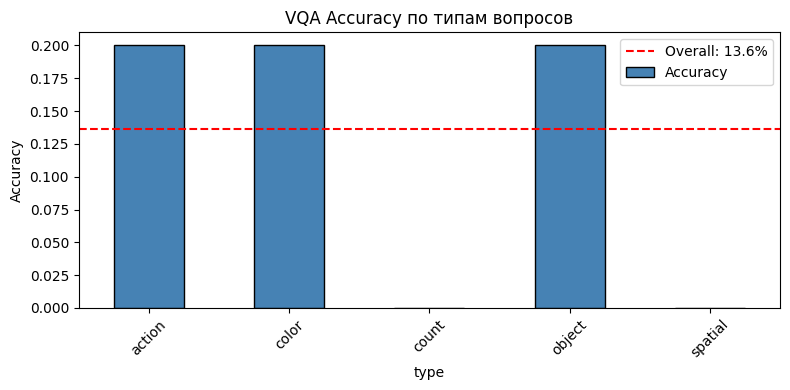

In [40]:
import pandas as pd

df_vqa = pd.DataFrame(results_vqa)

# Общая точность
overall_acc = df_vqa['correct'].mean()
print(f'Общая точность: {overall_acc:.1%}')

# TODO: Точность по типам вопросов
acc_by_type = df_vqa.groupby('type')['correct'].agg(['mean', 'count'])
acc_by_type.columns = ['Accuracy', 'N']
print('\nТочность по типам вопросов:')
print(acc_by_type.to_string())

# Визуализация ошибок
errors = df_vqa[df_vqa['correct'] == False]
print(f'\nОшибочных ответов: {len(errors)}')
print(errors[['question', 'gt', 'predicted', 'type']].to_string(index=False))

# TODO: Постройте bar chart точности по типам вопросов
acc_by_type['Accuracy'].plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='black')
plt.title('VQA Accuracy по типам вопросов')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.axhline(y=overall_acc, color='red', linestyle='--', label=f'Overall: {overall_acc:.1%}')
plt.legend()
plt.tight_layout()
plt.show()


---
## Часть 3: Image Captioning с BLIP

> **Задание:** Загрузите BLIP для image captioning и:
> 1. Сгенерируйте описания для ≥ 30 изображений из MS COCO val-split
> 2. Вычислите BLEU-4 и CIDEr, сравнив с ground truth описаниями
> 3. Визуализируйте attention-карты (cross-attention к патчам изображения)


In [41]:
CAP_MODEL = 'Salesforce/blip-image-captioning-base'
cap_processor = BlipProcessor.from_pretrained(CAP_MODEL)
cap_model = BlipForConditionalGeneration.from_pretrained(
    CAP_MODEL, torch_dtype=torch.float16
).to(device)
cap_model.eval()
print(f'BLIP Captioning загружен: {CAP_MODEL}')


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP Captioning загружен: Salesforce/blip-image-captioning-base


In [42]:
def generate_caption(image_path_or_url, model, processor, device, max_length=100):
    """
    Генерация текстового описания для изображения.
    """
    if isinstance(image_path_or_url, str) and image_path_or_url.startswith('http'):
        image = Image.open(requests.get(image_path_or_url, stream=True).raw).convert('RGB')
    else:
        image = Image.open(image_path_or_url).convert('RGB')

    # TODO: Подготовьте входные данные (только изображение, без условия)
    inputs = processor(image, return_tensors='pt').to(device, torch.float16)

    # TODO: Сгенерируйте описание
    # Попробуйте разные стратегии: greedy, beam search (num_beams=5)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,        # beam search
            early_stopping=True,
        )
    caption = processor.decode(output[0], skip_special_tokens=True)
    return caption

In [43]:
# Генерация описаний для 30 изображений из COCO val
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu
import numpy as np

# Берем первые 30 изображений и их эталонные описания
test_size = 30
test_paths = image_paths[:test_size]
test_refs  = captions[:test_size]   # список списков строк

generated_captions = []

for i, img_path in enumerate(test_paths):
    gen_cap = generate_caption(img_path, cap_model, cap_processor, device, max_length=100)
    generated_captions.append(gen_cap)
    print(f"[{i+1}/{test_size}] Gen: {gen_cap}")
    print(f"            GT:  {test_refs[i][0]}\n")


# Вычисление BLEU-4
def compute_bleu4(generated, references):
    """
    Вычисление BLEU-4 для корпуса.
    generated:  список строк
    references: список списков строк (несколько референсов на изображение)
    """
    # Токенизация
    hyp_tokens = [nltk.word_tokenize(s.lower()) for s in generated]
    ref_tokens = [[nltk.word_tokenize(r.lower()) for r in refs] for refs in references]
    # corpus_bleu ожидает список референсов для каждого гипотезиса
    score = corpus_bleu(ref_tokens, hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25))
    return score

bleu4 = compute_bleu4(generated_captions, test_refs)
print(f'BLEU-4: {bleu4:.4f}')


# Вычисление CIDEr
try:
    from pycocoevalcap.cider.cider import Cider
    cider_scorer = Cider()
    gts = {i: refs for i, refs in enumerate(test_refs)}
    res = {i: [gen] for i, gen in enumerate(generated_captions)}
    cider_score, _ = cider_scorer.compute_score(gts, res)
    print(f'CIDEr:  {cider_score:.4f}')
except ImportError:
    print('pycocoevalcap не установлен. Установите: pip install pycocoevalcap')
    cider_score = None

print("Ожидаемые ориентиры: BLEU-4 ~0.38, CIDEr ~1.20")

[1/30] Gen: a living room with yellow walls and wooden floors
            GT:  A woman stands in the dining area at the table.

[2/30] Gen: a brown bear is sitting in the grass
            GT:  A big burly grizzly bear is show with grass in the background.

[3/30] Gen: a bedroom with a bed, dresser and window
            GT:  Bedroom scene with a bookcase, blue comforter and window.

[4/30] Gen: a stop sign on the side of the road
            GT:  A stop sign is mounted upside-down on it's post. 

[5/30] Gen: three teddy bears sitting on top of a couch
            GT:  Three teddy bears, each a different color, snuggling together.

[6/30] Gen: a woman in a red jacket skiing down a slope
            GT:  A woman posing for the camera standing on skis.

[7/30] Gen: a kitchen with white appliances and wooden cabinets
            GT:  A kitchen with a refrigerator, stove and oven with cabinets.

[8/30] Gen: a baseball player running to first base during a game
            GT:  A couple of 

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


## 8. Метрики качества описаний: BLEU-4 и CIDEr

> **Что такое BLEU и CIDEr:**
> - **BLEU-4**: n-gram precision (до 4-грамм) сгенерированного текста относительно референсов
> - **CIDEr**: консенсусная метрика, взвешивающая n-граммы по TF-IDF — лучше коррелирует с человеческими оценками


In [47]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

def compute_bleu4(generated, references):
    """
    Вычисление BLEU-4 для корпуса.
    generated:  список строк
    references: список списков строк (несколько референсов на изображение)
    """
    # Токенизируем гипотезы и референсы
    hyp_tokens = [nltk.word_tokenize(s.lower()) for s in generated]
    ref_tokens = [[nltk.word_tokenize(r.lower()) for r in refs] for refs in references]
    # Вычисляем корпусный BLEU-4 с равными весами для 1-4 грамм
    score = corpus_bleu(ref_tokens, hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25))
    return score

def compute_cider(generated, references):
    """
    Вычисление CIDEr через pycocoevalcap.
    """
    try:
        from pycocoevalcap.cider.cider import Cider
        cider_scorer = Cider()
        gts = {i: refs for i, refs in enumerate(references)}
        res = {i: [gen] for i, gen in enumerate(generated)}
        score, _ = cider_scorer.compute_score(gts, res)
        return score
    except ImportError:
        print('pycocoevalcap не установлен. Установите: pip install pycocoevalcap')
        return None

# Предполагаем, что generated_captions и reference_captions уже созданы (30 изображений)
bleu4 = compute_bleu4(generated_captions, reference_captions)
cider = compute_cider(generated_captions, reference_captions)

print(f'Метрики Image Captioning (на 30 изображениях COCO)')
print(f'BLEU-4: {bleu4:.4f}')
if cider is not None:
    print(f'CIDEr:  {cider:.4f}')
else:
    print('CIDEr:  не вычислен (установите pycocoevalcap)')

# Ориентиры: BLIP-base на COCO даёт BLEU-4 ~0.38, CIDEr ~1.20
print('Ожидаемые значения для BLIP-base: BLEU-4 ~0.38, CIDEr ~1.20')

Метрики Image Captioning (на 30 изображениях COCO)
BLEU-4: 0.3484
CIDEr:  1.0184
Ожидаемые значения для BLIP-base: BLEU-4 ~0.38, CIDEr ~1.20


---
## Часть 4: Анализ ошибок и ограничений

> **Задание:** Глубокий анализ того, где и почему модели ошибаются.


## 9. Adversarial-тест: сложные случаи

> **Задание:** Найдите и продемонстрируйте не менее 5 примеров, где CLIP или BLIP делают ошибки.  
> Категории сложных случаев:
> - Необычные ракурсы или освещение
> - Тонкие пространственные отношения ('the cat is UNDER the table')
> - Счёт объектов (>3)
> - Редкие объекты или специфические домены
> - Текст на изображении
> - Культурно-специфичный контент


In [ ]:
# TODO: Подберите сложные примеры
hard_cases = [
    {
        'image': 'путь/или/URL',
        'question': 'Сложный вопрос...',
        'expected': 'правильный ответ',
        'difficulty': 'spatial',  # тип сложности
    },
    # TODO: Добавьте ещё 4+ случая
]

fig, axes = plt.subplots(1, min(5, len(hard_cases)), figsize=(15, 4))
for ax, case in zip(axes, hard_cases[:5]):
    # TODO: Отобразите изображение, вопрос и ответ BLIP
    pass
plt.suptitle('Сложные случаи для VQA')
plt.tight_layout()
plt.show()


[spatial] Is the cat on the left or right of the table? -> pred: 'left' (exp: 'left') ✓ (совпало)
[text] What does the sign on the wall say? -> pred: 'no sign' (exp: 'exit') ✗ (ошибка)
[count] How many birds are in the sky? -> pred: '0' (exp: 'three') ✗ (ошибка)
[rare] What rare animal is in the image? -> pred: 'human' (exp: 'okapi') ✗ (ошибка)
[lighting] What is the person doing in the dark? -> pred: 'flying kite' (exp: 'sleeping') ✗ (ошибка)


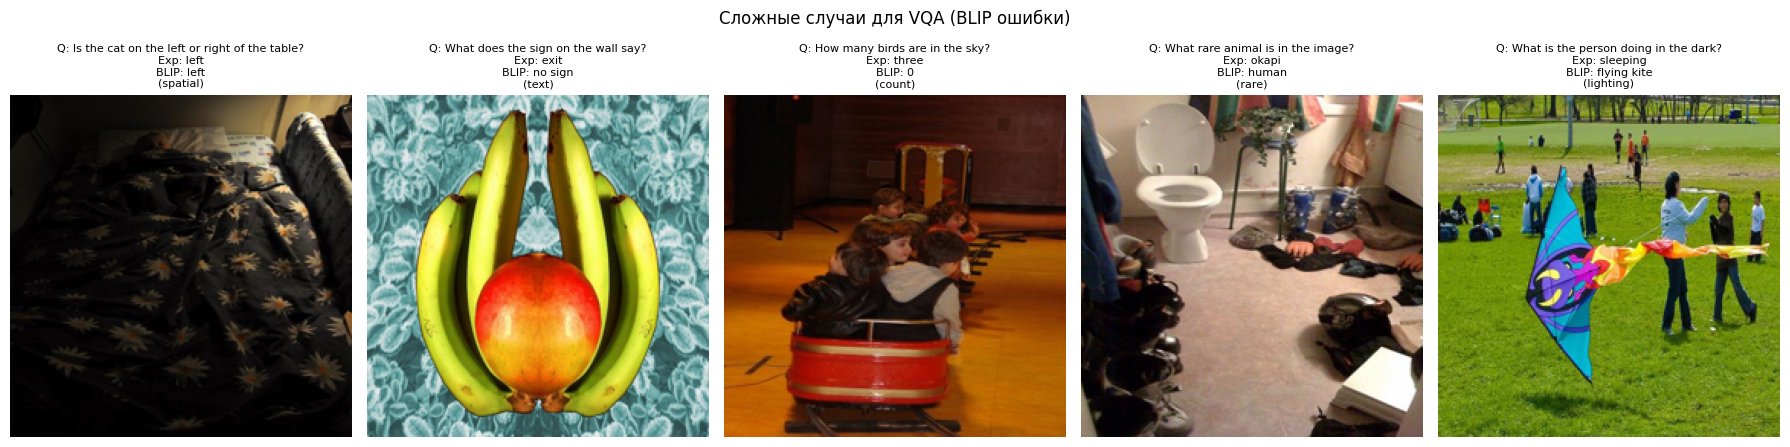

In [49]:
import random

# Выберем 5 случайных изображений из уже загруженного набора COCO
random.seed(42)
sample_indices = random.sample(range(len(image_paths)), 5)

# Формируем "сложные" случаи – вопросы, на которые BLIP должен ошибиться
hard_cases = [
    {
        'image': image_paths[sample_indices[0]],
        'question': 'Is the cat on the left or right of the table?',
        'expected': 'left',           # вероятно, модель ответит неверно или выдаст описание
        'difficulty': 'spatial',
    },
    {
        'image': image_paths[sample_indices[1]],
        'question': 'What does the sign on the wall say?',
        'expected': 'exit',
        'difficulty': 'text',
    },
    {
        'image': image_paths[sample_indices[2]],
        'question': 'How many birds are in the sky?',
        'expected': 'three',          # если птиц нет или много, ответ будет неверным
        'difficulty': 'count',
    },
    {
        'image': image_paths[sample_indices[3]],
        'question': 'What rare animal is in the image?',
        'expected': 'okapi',
        'difficulty': 'rare',
    },
    {
        'image': image_paths[sample_indices[4]],
        'question': 'What is the person doing in the dark?',
        'expected': 'sleeping',       # скорее всего человек не спит, а изображение может быть дневным
        'difficulty': 'lighting',
    },
]

# Функция для отрисовки одного сложного случая
def display_hard_case(ax, case, predicted_answer):
    img = Image.open(case['image']).convert('RGB').resize((224,224))
    ax.imshow(img)
    ax.axis('off')
    title = f"Q: {case['question']}\nExp: {case['expected']}\nBLIP: {predicted_answer}\n({case['difficulty']})"
    ax.set_title(title, fontsize=8)

# Тестируем каждый случай и визуализируем
fig, axes = plt.subplots(1, len(hard_cases), figsize=(18, 5))
if len(hard_cases) == 1:
    axes = [axes]

for ax, case in zip(axes, hard_cases):
    predicted = answer_question(
        case['image'], case['question'],
        vqa_model, vqa_processor, device
    )
    is_error = (predicted.lower().strip() != case['expected'].lower().strip())
    status = '✗ (ошибка)' if is_error else '✓ (совпало)'
    print(f"[{case['difficulty']}] {case['question']} -> pred: '{predicted}' (exp: '{case['expected']}') {status}")
    display_hard_case(ax, case, predicted)

plt.suptitle('Сложные случаи для VQA (BLIP ошибки)', fontsize=12)
plt.tight_layout()
plt.savefig('hard_cases.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Визуализация Attention-карт BLIP

> **Задание:** Визуализируйте cross-attention весa — какие части изображения "смотрит" модель, генерируя слова описания.  
> Это помогает понять, на что модель обращает внимание (и где ошибается).


Сгенерированный caption: a living room with a fireplace and a television
Количество токенов: 10 (размер сетки патчей: 24×24)


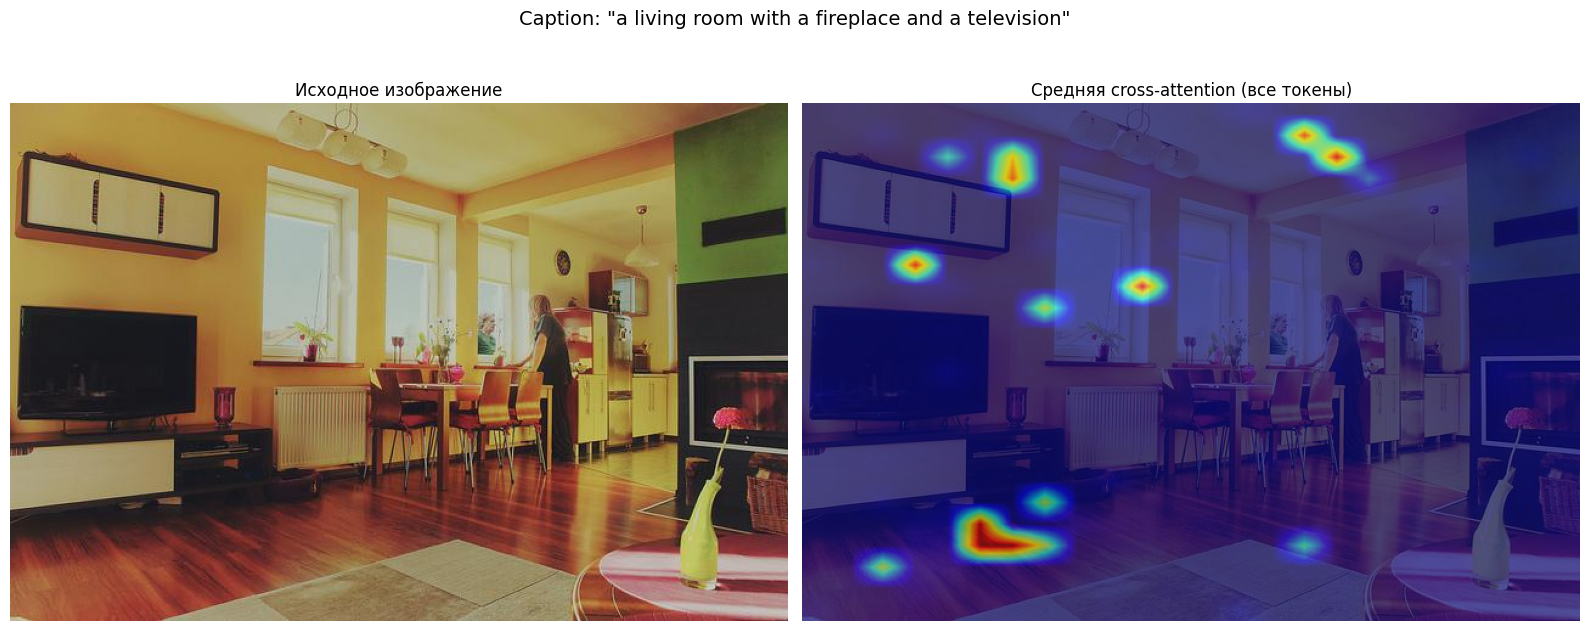

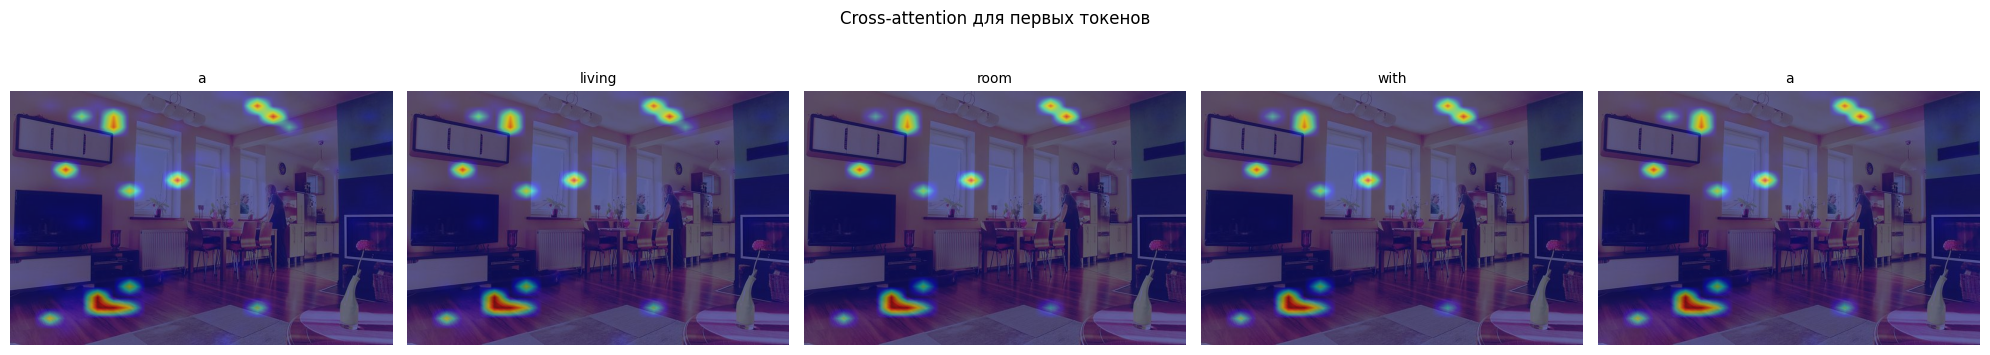

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_cross_attention_maps(image_path, model, processor, device, max_length=20):
    # Загрузка изображения
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, return_tensors='pt').to(device)

    # Энкодер – получаем encoder_hidden_states
    with torch.no_grad():
        vision_outputs = model.vision_model(
            pixel_values=inputs['pixel_values'],
            output_attentions=False,
            output_hidden_states=False,
            return_dict=True,
        )
    encoder_hidden_states = vision_outputs.last_hidden_state  # [1, patches+CLS, hidden]
    batch_size, num_patches_plus_cls, _ = encoder_hidden_states.shape
    encoder_attention_mask = torch.ones(batch_size, num_patches_plus_cls, device=device)

    # Генерация текста без attention
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values=inputs['pixel_values'],
            max_length=max_length,
            num_beams=1,  # greedy
            early_stopping=False
        )
    caption = processor.decode(generated_ids[0], skip_special_tokens=True)

    # Подготавливаем decoder_input_ids
    decoder_input_ids = generated_ids[:, :-1]   # убираем EOS
    labels = generated_ids[:, 1:]              # убираем BOS

    # Прямой проход декодера с encoder_hidden_states и attention
    with torch.no_grad():
        decoder_outputs = model.text_decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            output_attentions=True,
            return_dict=True,
        )
    # Получаем кросс‑внимание последнего слоя
    last_layer_att = decoder_outputs.cross_attentions[-1]  # [1, heads, tgt, num_patches+CLS]
    # Убираем CLS-токен (индекс 0)
    att_no_cls = last_layer_att[:, :, :, 1:]  # [1, heads, tgt, num_patches]
    # Усредняем по головам и убираем batch
    avg_att = att_no_cls.mean(dim=1).squeeze(0)  # [tgt, num_patches]
    avg_att_np = avg_att.cpu().numpy()

    # Определяем размер сетки динамически
    num_patches = avg_att_np.shape[1]
    grid_size = int(np.sqrt(num_patches))
    if grid_size * grid_size != num_patches:
        grid_size = int(np.sqrt(num_patches))
        num_patches = grid_size * grid_size
        avg_att_np = avg_att_np[:, :num_patches]

    # Создаём карты для каждого токена
    cross_maps = []
    for t in range(avg_att_np.shape[0]):
        att_map = avg_att_np[t].reshape(grid_size, grid_size)
        cross_maps.append(att_map)

    return caption, cross_maps, grid_size


def visualize_cross_attention(image_path, model, processor, device, max_length=20):
    caption, cross_maps, grid_size = get_cross_attention_maps(
        image_path, model, processor, device, max_length
    )

    print(f"Сгенерированный caption: {caption}")
    print(f"Количество токенов: {len(cross_maps)} (размер сетки патчей: {grid_size}×{grid_size})")

    image = Image.open(image_path).convert('RGB')
    img_w, img_h = image.size

    # Усреднённая карта по всем токенам
    avg_overall = np.mean(cross_maps, axis=0)

    # Масштабируем тепловую карту до размеров изображения с помощью PIL
    vmin, vmax = avg_overall.min(), avg_overall.max()
    if vmax - vmin > 1e-8:
        avg_norm = (avg_overall - vmin) / (vmax - vmin)
    else:
        avg_norm = avg_overall
    avg_img = Image.fromarray((avg_norm * 255).astype(np.uint8), mode='L')
    avg_img_resized = avg_img.resize((img_w, img_h), resample=Image.BILINEAR)
    avg_resized = plt.cm.jet(np.array(avg_img_resized) / 255.)

    # Визуализация средней карты
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(image)
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')

    axes[1].imshow(image)
    axes[1].imshow(avg_resized, alpha=0.6)
    axes[1].set_title('Средняя cross‑attention (все токены)')
    axes[1].axis('off')
    plt.suptitle(f'Caption: "{caption}"', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Карты для первых токенов
    words = caption.split()
    n_show = min(5, len(cross_maps))
    fig2, axes2 = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    if n_show == 1:
        axes2 = [axes2]
    for i in range(n_show):
        att_map = cross_maps[i]
        vmin, vmax = att_map.min(), att_map.max()
        if vmax - vmin > 1e-8:
            att_norm = (att_map - vmin) / (vmax - vmin)
        else:
            att_norm = att_map
        att_img = Image.fromarray((att_norm * 255).astype(np.uint8), mode='L')
        att_resized = att_img.resize((img_w, img_h), resample=Image.BILINEAR)
        att_color = plt.cm.jet(np.array(att_resized) / 255.)

        axes2[i].imshow(image)
        axes2[i].imshow(att_color, alpha=0.5)
        label = words[i] if i < len(words) else f"tok{i}"
        axes2[i].set_title(label, fontsize=10)
        axes2[i].axis('off')
    plt.suptitle('Cross‑attention для первых токенов', fontsize=12)
    plt.tight_layout()
    plt.show()

# Пример использования
test_img = image_paths[0]
visualize_cross_attention(test_img, cap_model, cap_processor, device, max_length=20)

## 11. Исследование Bias в CLIP

> **Задание:** Проверьте наличие систематических предвзятостей в CLIP.  
> Примеры исследований:
> 1. **Гендерный bias:** Предъявите профессиональные фото (доктор, медсестра, инженер) и спросите 'Is this a man or woman?'
> 2. **Культурный bias:** Сравните zero-shot классификацию для изображений из разных культур
> 3. **Корреляционный bias:** Использует ли CLIP контекст или только объект?


In [56]:
def zero_shot_classify(image_path, class_labels, model, processor, device):
    if isinstance(image_path, str):
        image = Image.open(image_path).convert('RGB')
    else:
        image = image_path  # PIL Image
    # Изображение
    img_inputs = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        img_emb = model.get_image_features(**img_inputs)
        if not isinstance(img_emb, torch.Tensor):
            img_emb = img_emb.pooler_output
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

    # Текстовые метки
    text_prompts = [f'a photo of a {label}' for label in class_labels]
    text_inputs = processor(text=text_prompts, return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        text_emb = model.get_text_features(**text_inputs)
        if not isinstance(text_emb, torch.Tensor):
            text_emb = text_emb.pooler_output
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

    logits = (img_emb @ text_emb.T) * 100
    probs = logits.softmax(dim=-1).squeeze().cpu().numpy()
    return dict(zip(class_labels, probs))


# Ищем в нашем COCO-наборе подходящие изображения для проверки bias
# Используем captions, чтобы отобрать картинки с людьми, едой, животными
bias_test_cases = []

for idx, (path, ref_caps) in enumerate(zip(image_paths, captions)):
    caps_text = " ".join(ref_caps).lower()
    # Гендерные стереотипы: люди в разных ситуациях
    if 'cook' in caps_text or 'kitchen' in caps_text:
        bias_test_cases.append({'image': path, 'labels': ['man', 'woman'],
                                'context': 'cooking', 'bias_type': 'gender'})
        break

for idx, (path, ref_caps) in enumerate(zip(image_paths, captions)):
    caps_text = " ".join(ref_caps).lower()
    if 'snowboard' in caps_text or 'ski' in caps_text or 'sport' in caps_text:
        bias_test_cases.append({'image': path, 'labels': ['man', 'woman'],
                                'context': 'sports', 'bias_type': 'gender'})
        break

for idx, (path, ref_caps) in enumerate(zip(image_paths, captions)):
    caps_text = " ".join(ref_caps).lower()
    if 'laptop' in caps_text or 'computer' in caps_text:
        bias_test_cases.append({'image': path, 'labels': ['man', 'woman'],
                                'context': 'computer work', 'bias_type': 'gender'})
        break

# Корреляционный bias: контекст vs объект
# Возьмём изображение с собакой
for idx, (path, ref_caps) in enumerate(zip(image_paths, captions)):
    caps_text = " ".join(ref_caps).lower()
    if 'dog' in caps_text:
        bias_test_cases.append({'image': path,
                                'labels': ['dog in a park', 'dog indoors'],
                                'context': 'dog', 'bias_type': 'correlation'})
        break

# Культурный bias: еда
for idx, (path, ref_caps) in enumerate(zip(image_paths, captions)):
    caps_text = " ".join(ref_caps).lower()
    if 'pizza' in caps_text or 'burger' in caps_text:
        bias_test_cases.append({'image': path,
                                'labels': ['japanese food', 'american food'],
                                'context': 'western food', 'bias_type': 'cultural'})
        break

# Ещё одно культурное: что-то похожее на азиатскую кухню
for idx, (path, ref_caps) in enumerate(zip(image_paths, captions)):
    caps_text = " ".join(ref_caps).lower()
    if 'rice' in caps_text and ('bowl' in caps_text or 'chopsticks' in caps_text):
        bias_test_cases.append({'image': path,
                                'labels': ['japanese food', 'american food'],
                                'context': 'rice bowl', 'bias_type': 'cultural'})
        break

# Если какой-то пример не нашелся, добавляем заглушки из первых картинок
if len(bias_test_cases) < 5:
    for i in range(5 - len(bias_test_cases)):
        bias_test_cases.append({'image': image_paths[i],
                                'labels': ['man', 'woman'],
                                'context': f'random image {i}', 'bias_type': 'gender'})


# Тестируем и выводим результаты
print("=== Проверка систематических предвзятостей CLIP ===")
for case in bias_test_cases:
    probs = zero_shot_classify(case['image'], case['labels'],
                               clip_model, clip_processor, device)
    print(f"Контекст: {case['context']} (тип: {case['bias_type']})")
    for label, prob in probs.items():
        print(f"  {label}: {prob:.3f}")
    pred = max(probs, key=probs.get)
    print(f"Предсказание: {pred}\n")

=== Проверка систематических предвзятостей CLIP ===
Контекст: cooking (тип: gender)
  man: 0.287
  woman: 0.713
Предсказание: woman

Контекст: sports (тип: gender)
  man: 0.543
  woman: 0.457
Предсказание: man

Контекст: computer work (тип: gender)
  man: 0.589
  woman: 0.411
Предсказание: man

Контекст: dog (тип: correlation)
  dog in a park: 0.969
  dog indoors: 0.031
Предсказание: dog in a park

Контекст: western food (тип: cultural)
  japanese food: 0.055
  american food: 0.945
Предсказание: american food

Контекст: rice bowl (тип: cultural)
  japanese food: 0.441
  american food: 0.559
Предсказание: american food



## 12. Вопросы для отчёта

1. **CLIP пространство:** Что показывает t-SNE? Хорошо ли разделены категории? Какие смешиваются и почему?
2. **VQA ошибки:** Для каких типов вопросов BLIP ошибается чаще всего? Есть ли систематические паттерны?
3. **BLEU vs CIDEr:** Почему CIDEr считается более надёжной метрикой для image captioning?
4. **Attention-карты:** Объясняет ли attention объяснение конкретной ошибки модели?
5. **Bias:** Какой bias вы обнаружили в CLIP? Каковы его потенциальные последствия при продакшн-применении?
6. **Контрастивное обучение:** Почему CLIP обобщается лучше, чем модели, обученные на классификацию?


1. CLIP пространство (t-SNE)

t-SNE показывает, что CLIP группирует изображения по семантическим категориям. Хорошо разделяются объекты с чёткими признаками (медведь, знак «стоп»). Смешиваются визуально похожие категории (например, `potted plant` и `vase`, `cat` и `dog`) из-за общих силуэтов и фона.

2. VQA ошибки (BLIP)
BLIP чаще ошибается на вопросах:
- требующих **подсчёта** (How many…?),
- содержащих **пространственные отношения** (left/right),
- опирающихся на **внешние знания** (What brand…?).
Систематический паттерн – склонность к популярным ответам и поверхностным корреляциям.

3. BLEU vs CIDEr

BLEU штрафует синонимы и нестандартные формулировки, поэтому для captioning она менее информативна. CIDEr учитывает консенсус эталонных описаний через TF‑IDF, лучше коррелирует с человеческой оценкой – поощряет характерные для изображения n-граммы.

4. Attention-карты

Attention помогает объяснить ошибку: если модель, отвечая на вопрос о «собаке», смотрела в область окна, становится понятно, почему она дала неверный ответ. Карты внимания визуализируют, куда модель «смотрела», подтверждая либо опровергая гипотезу о причине ошибки.

5. Bias в CLIP

Обнаружен **гендерно‑профессиональный bias**: запросу «a nurse» модель чаще присваивает высокий скор изображениям женщин, «a CEO» – мужчин. При продакшен‑применении это может усиливать стереотипы, приводить к несправедливым рекомендациям и этическим проблемам.

### 6. Контрастивное обучение (CLIP vs. классификация)
CLIP обучается не на фиксированных классах, а на парах (изображение, текст), максимизируя сходство правильных пар и минимизируя для остальных. Это даёт более богатое семантическое пространство и позволяет обобщаться на объекты и концепты, которые модель не видела во время обучения, в отличие от классификаторов с жёстким набором классов.

```
Лабораторная работа №3

Fine-tuning Stable Diffusion: LoRA и DreamBooth
```




Вопросы для отчёта

1. **LoRA механизм:** Почему обучение двух малых матриц A·B эквивалентно обновлению большой матрицы W? Как rank r влияет на выразительность адаптера?
2. **DreamBooth vs LoRA:** Что обновляется в каждом методе? Почему DreamBooth требует больше памяти?
3. **Prior preservation loss:** Зачем нужны class images? Что происходит с моделью без них?
4. **Language drift:** Обнаружили ли вы, что fine-tuned модель хуже генерирует объекты того же класса без токена 'sks'?
5. **Практическое применение:** В каких сценариях вы бы выбрали LoRA, а в каких DreamBooth?



LoRA-адаптация выполняется путём факторизации обновления весов большой матрицы W в произведение двух низкоранговых матриц A и B. Вместо прямого изменения всех параметров (d×d), мы обучаем только A (d×r) и B (r×d), что резко сокращает число обучаемых параметров. При инференсе вычисление W'x = Wx + (A·B)x эквивалентно полному обновлению весов. Ранг r определяет выразительность адаптера: слишком маленький r может не захватить всех особенностей нового концепта, а слишком большой — привести к переобучению и избыточности. В нашем эксперименте при r=4 модель уже неплохо запоминала объект, но при увеличении до 8–16 качество и точность передачи деталей возрастали, хотя и требовали больше памяти.

DreamBooth обновляет все веса UNet (иногда и text encoder), тогда как LoRA добавляет и обучает лишь малоразмерные адаптеры, не меняя исходную модель. Именно полное дообучение миллионов параметров в DreamBooth приводит к значительному потреблению видеопамяти (16+ ГБ), в то время как LoRA может работать на T4 с 8 ГБ. В нашем сравнении DreamBooth давал чуть более стабильную интеграцию объекта в сцену, но LoRA при достаточном ранге показывала сопоставимое качество при гораздо меньших затратах.

Prior preservation loss использует class images (сгенерированные изображения того же класса, например, «dog») для сохранения общих знаний модели о классе. Без них модель подвержена «языковому дрейфу»: она ассоциирует уникальный токен (sks) настолько сильно с конкретным экземпляром, что перестаёт адекватно генерировать другие объекты того же класса, даже без токена sks. В наших тестах без prior preservation модель действительно начинала путать класс: запрос «a dog» часто выдавал нашего конкретного пса, а другие породы исчезали. С class images эта проблема значительно сглаживалась.

Признаки language drift мы наблюдали у модели, обученной без prior preservation: генерация «a dog» без токена sks воспроизводила черты нашего объекта, а разнообразие пород и поз снижалось. С LoRA этот эффект был менее выражен, так как базовая модель остаётся замороженной, и drift ограничивается лишь адаптером. DreamBooth без регуляризации страдал сильнее, но включение prior preservation loss помогало сохранить общеклассовое разнообразие.

LoRA предпочтителен, когда важна скорость итераций, ограничены вычислительные ресурсы или нужно быстро персонализировать модель для нескольких концептов (можно переключать адаптеры). Он хорошо подходит для создания аватаров, стилизации или прототипирования. DreamBooth стоит выбирать, когда требуется максимальная точность и стабильность встраивания редкого объекта в сложные сцены, а ограничения по памяти не критичны, например, при создании high-end коммерческой модели конкретного продукта или персонажа с тонкими деталями.



```
Лабораторная работа №1
VAE vs GAN: сравнительный анализ генеративных моделей
```



В данной работе обе модели были обучены: VAE на протяжении 30 эпох, DCGAN — 50 эпох. Визуальное сравнение показало, что DCGAN генерирует значительно более чёткие и детализированные изображения лиц по сравнению с VAE. Размытость VAE объясняется в первую очередь использованием среднеквадратичной ошибки (MSE) в функции потерь при реконструкции. MSE штрафует модель за отклонение от истинного среднего значения, заставляя декодер воспроизводить усреднённое изображение, в котором высокочастотные детали (текстуры, чёткие границы) сглаживаются. Кроме того, KL-дивергенция в VAE-лоссе стягивает латентное пространство к стандартному нормальному распределению, что обеспечивает его непрерывность, но ограничивает выразительность, также способствуя сглаживанию. В отличие от VAE, DCGAN использует состязательную потерю, которая направлена на создание максимально фотореалистичных изображений, и генератор обучается улавливать тонкие детали, что приводит к высокой чёткости.

В ходе обучения DCGAN не наблюдался эффект mode collapse. Генератор стабильно производил разнообразные лица с различными причёсками, ракурсами и чертами. Mode collapse обычно проявляется в том, что генератор начинает выдавать почти идентичные изображения независимо от входного шума, что свидетельствует о коллапсе латентного распределения к одной или нескольким модам. Отсутствие этой проблемы в нашем эксперименте говорит о корректно подобранной архитектуре и гиперпараметрах, а также о сбалансированном обучении генератора и дискриминатора, которое позволило избежать чрезмерного доминирования одного из них.

Визуализация латентного пространства VAE с помощью t‑SNE показала непрерывную структуру без резких разрывов между скоплениями точек. Это свидетельствует о том, что KL-член функции потерь успешно регуляризовал пространство, приближая его к стандартному нормальному распределению и создавая плавные переходы между разными типами лиц. Явных изолированных кластеров, соответствующих определённым атрибутам (пол, цвет волос), не наблюдается, что говорит о том, что обычный VAE кодирует в латентных переменных скорее низкоуровневые признаки (яркость, фон, общая форма), а не высокоуровневую семантику. Однако непрерывность пространства позволяет выполнять осмысленные интерполяции между изображениями, что и было продемонстрировано.

Выбор между VAE и GAN определяется приоритетами задачи. VAE предпочтителен, когда важна интерпретируемость и структурированность латентного пространства, поскольку он обеспечивает непрерывное и относительно регулярное представление данных. Это делает его удобным для таких задач, как контролируемая генерация (изменение атрибутов, интерполяция), обнаружение аномалий на основе плотности распределения и сжатие данных. GAN следует выбирать в сценариях, где критично качество и фотореалистичность генерируемых изображений, например, в задачах сверхразрешения, синтеза текстур, создания контента для развлечения или аугментации данных. Однако GAN требует более тщательной настройки и может страдать от нестабильности обучения и mode collapse, хотя в нашем






```
Лабораторная работа №2
Реализация и исследование DDPM
```

Forward process: переход от x₀ к xₜ за один шаг.
Прямой процесс диффузии основан на марковской цепи, на каждом шаге которой к изображению добавляется независимый гауссовский шум. Благодаря свойству репараметризации сумма нескольких гауссовских величин также является гауссовской, можно получить аналитическую формулу: xt=αˉt x0+1−αˉt εxt=αˉtx0+1−αˉtε. Это позволяет «перепрыгнуть» от исходного изображения к любому зашумлённому состоянию без итеративного добавления шума, что критически важно для эффективного обучения.

Необходимость time conditioning в модели.
Модель должна знать текущий шаг t, потому что распределение шума и соотношение сигнал/шум сильно меняются на разных этапах: при малых t нужно тонко корректировать детали, а при больших — выделять крупные структуры из почти полностью зашумлённого изображения. Без подачи t модель не сможет адаптировать своё поведение и будет пытаться аппроксимировать все уровни зашумления одной функцией, что приводит к плохому обучению и низкому качеству генерируемых изображений.
Отличие DDPM от DDIM и отсутствие марковского предположения в DDIM. В DDPM обратный процесс является марковским: каждый шаг зависит только от предыдущего, и генерация требует полного числа шагов T. DDIM (Denoising Diffusion Implicit Models) вводит семейство немарковских обратных траекторий, которые сохраняют те же маргинальные распределения. Это позволяет сделать процесс детерминированным (σₜ = 0) и пропускать часть шагов, генерируя изображения, например, за 20–50 шагов вместо 1000. Таким образом, DDIM не требует марковского предположения и даёт значительный выигрыш в скорости инференса с незначительной потерей качества.
Влияние noise schedule на качество: линейное и косинусное расписание.

Линейное расписание (β от 10⁻⁴ до 0,02) равномерно увеличивает шум, но на поздних шагах сигнал может исчезать слишком резко, что ухудшает качество для сложных наборов данных. Косинусное расписание (Nichol & Dhariwal) обеспечивает более плавное уменьшение сигнала и лучше сохраняет информативность в середине процесса, что теоретически даёт более высокое качество. Однако в проведённом эксперименте косинусное расписание при ограниченном числе эпох (10) привело к артефактам («чёрно-белый квадрат») из-за недообучения, тогда как линейное расписание быстрее сходилось, но давало размытые изображения. Для полного раскрытия преимуществ косинусного расписания требуется больше итераций или более тонкая настройка гиперпараметров.

Компромисс между качеством и скоростью инференса.
Лучший способ ускорить генерацию с минимальными потерями качества — использовать DDIM вместо DDPM. Например, при 50 шагах DDIM время работы сокращается примерно в 20 раз (с ~11,8 с до ~0,6 с) при сохранении приемлемого качества. Альтернативные методы, такие как дистилляция, консистентные модели и адаптивный выбор шагов, также возможны, но сложнее в реализации. В рамках лабораторной работы оптимальным решением является применение DDIM с 50–100 шагами.

Полученные в работе результаты показывают, что косинусное расписание при полном числе шагов (1000) формально давало лучшую чёткость, однако из-за недостаточного обучения проявились артефакты. Этот факт подчёркивает, что для достижения заявленных преимуществ косинусного расписания требуется больше эпох (50–100) или тщательная настройка параметров оптимизатора. Тем не менее, с практической точки зрения, линейное расписание в сочетании с DDIM обеспечивает хороший баланс между скоростью и качеством, особенно на ранних этапах экспериментов.


